In [140]:
%load_ext autoreload
%autoreload 2

import os
import sys
# import glob
# import dill as pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
import torch
import nibabel as nb

from tqdm.auto import tqdm

DATA7_PATH = "/System/Volumes/Data/data/data7"
projects_path = f"{DATA7_PATH}/network_control/projects"
sys.path.insert(1, projects_path)
import CAP_tools

NC_path = f"{DATA7_PATH}/network_control/projects/network_control"
sys.path.insert(1, NC_path)
import plot
import surface_mapping as sfm
import load

import voxel_analysis as va

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data:
### Parameters / Load ptseries and DTI-As

In [2]:
N_PARCELS = 400

data_types = ["rfMRI_REST1_7T_PA", "tfMRI_MOVIE_7T_DAY_1"]
data_exts = ["_hp2000_clean_nilearn", "_hp2000_clean_nilearn_ISCH"]

In [3]:
DTI_parcellation, fMRI_parcellation, _, subject_list = load.load_constants(N_PARCELS)
tf_arrays, template_cifti = load.load_ptseries(subject_list, data_types,
                                               data_exts, fMRI_parcellation)

rfMRI_all, tfMRI_all = tf_arrays["rfMRI_all"], tf_arrays["tfMRI_all"]
ROI_labels, network_labels = load.load_labels(template_cifti)

Loading ptseries:   0%|          | 0/172 [00:00<?, ?it/s]

### Load in CAP States

In [88]:
CAP_analysis_label = "tfMRI_MOVIE_7T_DAY_1"
isc = 0
K = 12
state_norm = 0

In [89]:
CAP_pkl_path = load.get_CAP_pkl_path(CAP_analysis_label, K, isc=isc)
CAP_states, CAP_labels, n_CAPs = load.load_CAPs(CAP_pkl_path, subject_list, tfMRI_all)

# Explained Variance of Voxel Data, Similarities, and ISCs

In [12]:
import torch_math_tools as tmt

from os.path import join as pjoin

In [163]:
param_dir = "/data/data7/network_control/scripts/_params"
HCP_CAP_param_prefix = pjoin(param_dir, "HCP_7T_CAP_analysis/HCP_7T_CAP_analysis")

get_HCP_cifti_list = lambda session, cifti_type: f"{HCP_CAP_param_prefix}_{session}_{cifti_type}_list.txt"

def get_cifti_paths(cifti_list_path):
    with open(cifti_list_path, "r") as file:
        return file.read().strip().split()

def filter_sort_cifti_paths(paths, subjects):
    filtered_paths = [p for p in paths if any(subj in p for subj in subjects)]
    assert len(filtered_paths) == len(subjects)
    key = lambda path: next(i for i, subj in enumerate(subjects) if subj in path)
    return sorted(filtered_paths, key=key)

def get_HCP_cifti_paths(session, cifti_type, subject_list):
    cifti_list_path = get_HCP_cifti_list(session, "dtseries")
    cifti_paths = get_cifti_paths(cifti_list_path)
    cifti_paths = filter_sort_cifti_paths(cifti_paths, subject_list)
    return cifti_paths

### Load Ciftis

In [167]:
session = "tfMRI_MOVIE_7T_DAY_1"
# session = "rfMRI_REST1_7T_PA"

dtseries_paths = get_HCP_cifti_paths(session, "dtseries", subject_list)
ptseries_paths = get_HCP_cifti_paths(session, "400_ptseries", subject_list)

In [168]:
subject_index = 0

dtseries = nb.load(dtseries_paths[subject_index])
ptseries = nb.load(ptseries_paths[subject_index])
voxel_data = dtseries.get_fdata()
parcel_data = ptseries.get_fdata()

### Cifti Map to Full Arrays

In [169]:
def hemisphere_to_full(values):
    """ """
    return np.concat([values["left"], values["right"]], axis=-1)

In [170]:
roi_i = 0
ri = np.arange(len(ROI_labels)) == roi_i
ri = np.arange(len(ROI_labels))

parcel_values = CAP_tools.utils.cifti_map(np.array(ROI_labels)[ri], parcel_data[:, ri], template_cifti)
parcelf_values = hemisphere_to_full(parcel_values)

voxel_values = CAP_tools.utils.cifti_map(None, voxel_data, dtseries)
voxelf_values = hemisphere_to_full(voxel_values)

## Example Voxel Level Frame

(<Axes: >, <surfplot.plotting.Plot at 0x1672baa50>)

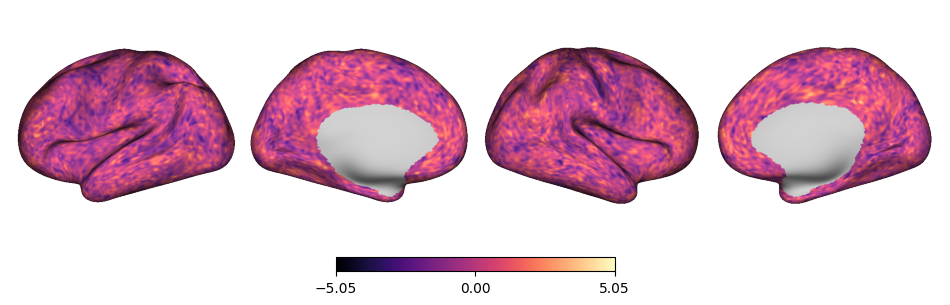

In [171]:
tr = 3
b_values = {"left": voxel_values["left"][tr], "right": voxel_values["right"][tr]}
sfm.surface_plot(b_values, cmap=plt.cm.magma)

# Assessing Dimensionality Reduction Techniques

Text(0.5, 1.0, 'Parcellation Explained Variance of Voxel BOLD Activity\ntfMRI_MOVIE_7T_DAY_1')

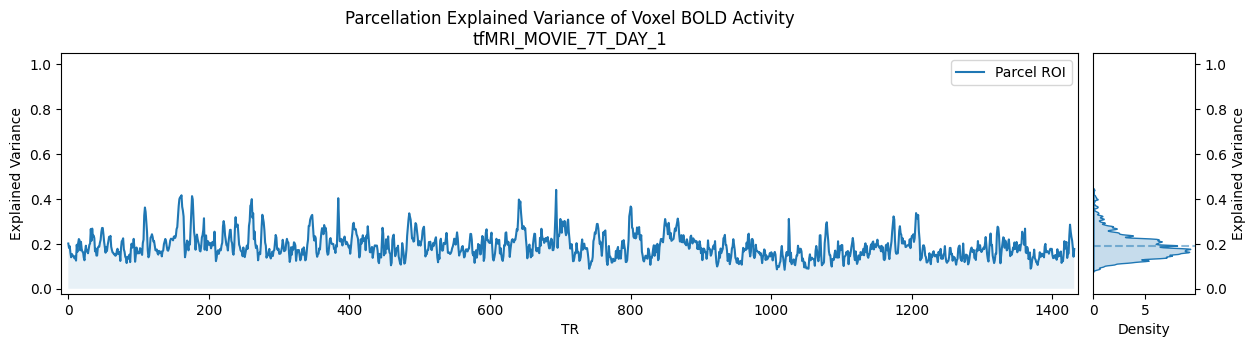

In [178]:
f_ni = ~ va.utils.get_shared_nan_index(voxelf_values, parcelf_values)
parcel_r_s = scipy.stats.pearsonr(parcelf_values[:, f_ni], voxelf_values[:, f_ni], axis=1)[0]
parcel_ev_s = r_s ** 2

a0, _ = va.plot.evar_timeseries_plot(parcel_ev_s, label="Parcel ROI")
a0.set_title(f"Parcellation Explained Variance of Voxel BOLD Activity\n{session}")

Text(0.5, 1.0, 'CAP State Explained Variance of Voxel BOLD Activity\ntfMRI_MOVIE_7T_DAY_1')

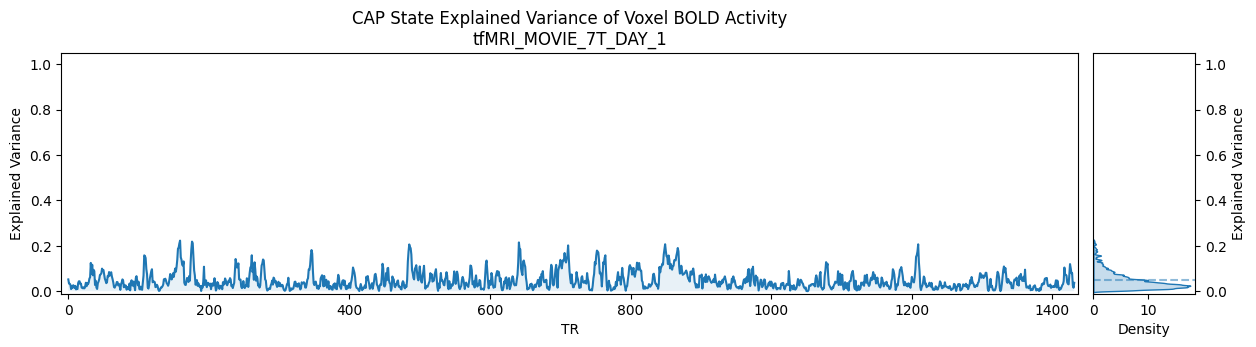

In [175]:
cap_set_values = CAP_tools.utils.cifti_map(ROI_labels, CAP_states, template_cifti)
cap_setf_values = hemisphere_to_full(cap_set_values)

capf_values = cap_setf_values[CAP_labels[subject_index]]

f_ni = ~ va.utils.get_shared_nan_index(voxelf_values, capf_values)
cap_r_s = scipy.stats.pearsonr(capf_values[:, f_ni], voxelf_values[:, f_ni], axis=1)[0]
cap_ev_s = cap_r_s ** 2

a0, _ = va.plot.evar_timeseries_plot(cap_ev_s, label="CAP State")
a0.set_title(f"CAP State Explained Variance of Voxel BOLD Activity\n{session}")

Text(0.5, 1.0, 'Explained Variance of Voxel BOLD Activity\ntfMRI_MOVIE_7T_DAY_1')

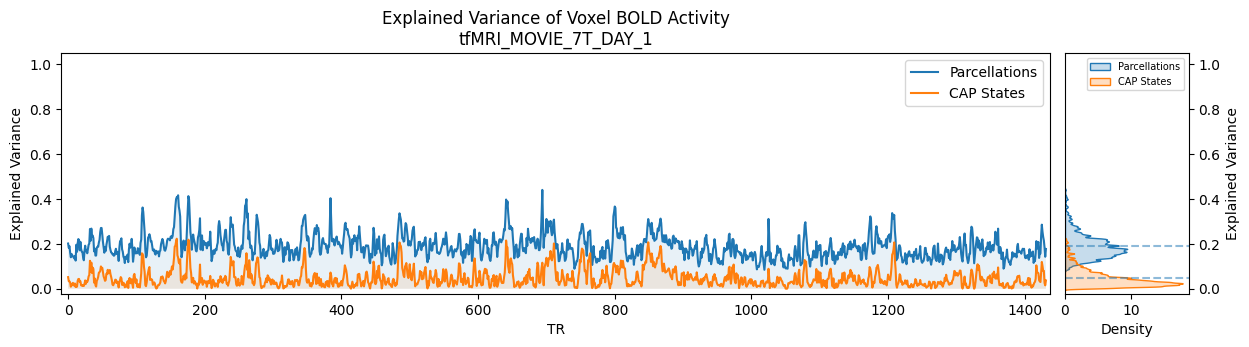

In [184]:
axes = va.plot.evar_timeseries_plot(parcel_ev_s, label="Parcellations")
axes = va.plot.evar_timeseries_plot(cap_ev_s, label="CAP States", axes=axes)
axes[0].set_title(f"Explained Variance of Voxel BOLD Activity\n{session}")

# Voxel-Voxel associations 

In [ ]:
ev_maxs = tmt.matrix.block_analysis(data[:, :10000], tmt.matrix.ev_aggregator,
                                    device="mps", use_torch=True)

In [56]:
(ev_maxs >= 0.5).mean() * 100

np.float64(86.18)

<Axes: ylabel='Density'>

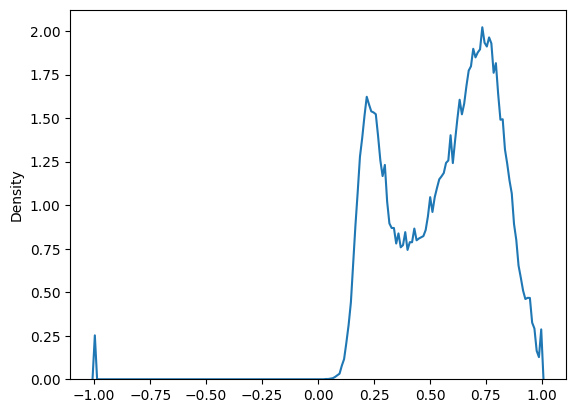

In [179]:
sns.kdeplot(ev_maxs, bw_method=0.01)

[] within parcel vs out of parcel correlations for voxel level

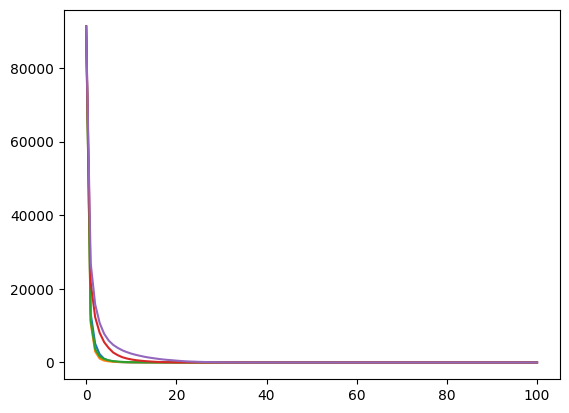

In [558]:
plt.plot(na_counts.T);

In [543]:
na_counts = {thres: [] for thres in np.linspace(0, 1, 101)}

# CAP Explained Variance of BOLD
- [] by subject
- [] over time (and by subject ?)

In [474]:
tfMRI_all.shape

(172, 1432, 400)

In [477]:
m = np.mean(tfMRI_all, axis=0)

In [496]:
r_s = np.array([scipy.stats.pearsonr(m, tf_i)[0] for tf_i in tfMRI_all])

In [497]:
r_s.shape

(172, 400)

In [505]:
ev_p = np.mean(r_s ** 2, axis=0)

(<Axes: >, <surfplot.plotting.Plot at 0x34c16be10>)

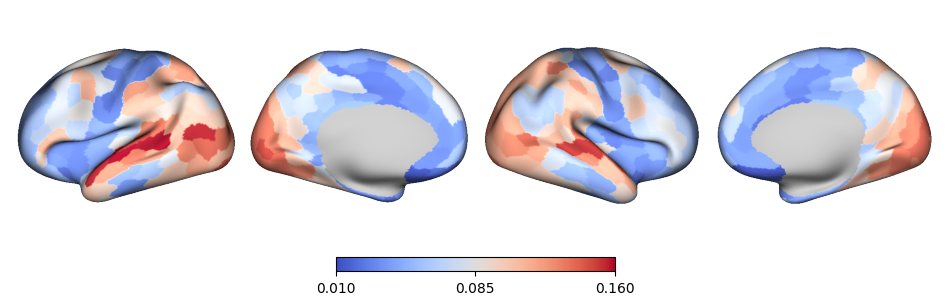

In [515]:
mapped_plot(np.std(r_s ** 2, axis=0), ROI_labels, template_cifti, alpha=1)

(<Axes: >, <surfplot.plotting.Plot at 0x341eb37d0>)

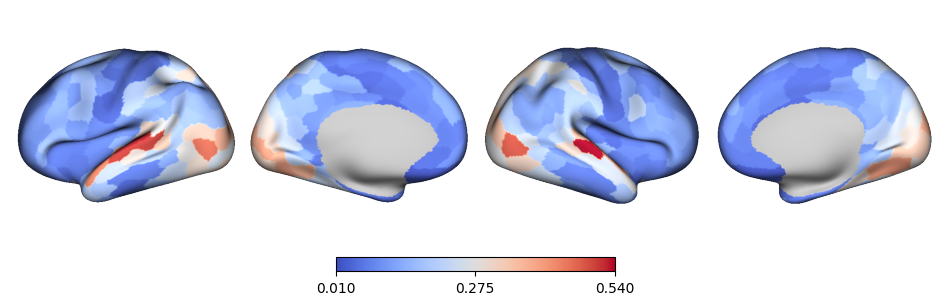

In [512]:
mapped_plot(ev_p, ROI_labels, template_cifti, alpha=1)

<Axes: ylabel='Density'>

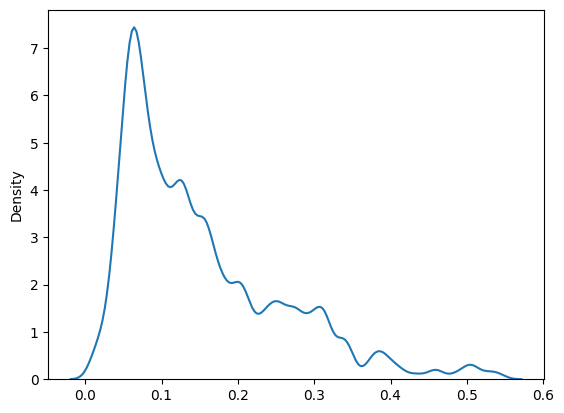

In [509]:
sns.kdeplot(ev_p, bw_method=0.1)

In [498]:
np.mean(r_s ** 2)

np.float64(0.15189458246906826)

In [250]:
CAP_traj = CAP_states[CAP_labels]

In [464]:
a = CAP_traj
b = tfMRI_all

r_s = scipy.stats.pearsonr(a.reshape(-1, a.shape[-1]).T, b.reshape(-1, b.shape[-1]).T)[0]
r_s = r_s.reshape(a.shape[:-1])
ev_s = r_s ** 2

In [471]:
subj_r_s = scipy.stats.pearsonr(a.reshape(a.shape[0], -1).T, b.reshape(b.shape[0], -1).T)[0]
subj_ev_s = subj_r_s ** 2

lower, upper = np.percentile(ev_s, 5), np.percentile(ev, 95)
s = f"Mean = {np.mean(subj_ev_s) * 100:.1f}% "
s += f"(90% CI {np.percentile(subj_ev_s, 5)*100:.1f}% - {np.percentile(subj_ev_s, 95)*100:.1f}%)"
print(s)

Mean = 19.8% (90% CI 16.5% - 22.7%)


[Text(965.8627180899908, 0.5, 'Explained Variance')]

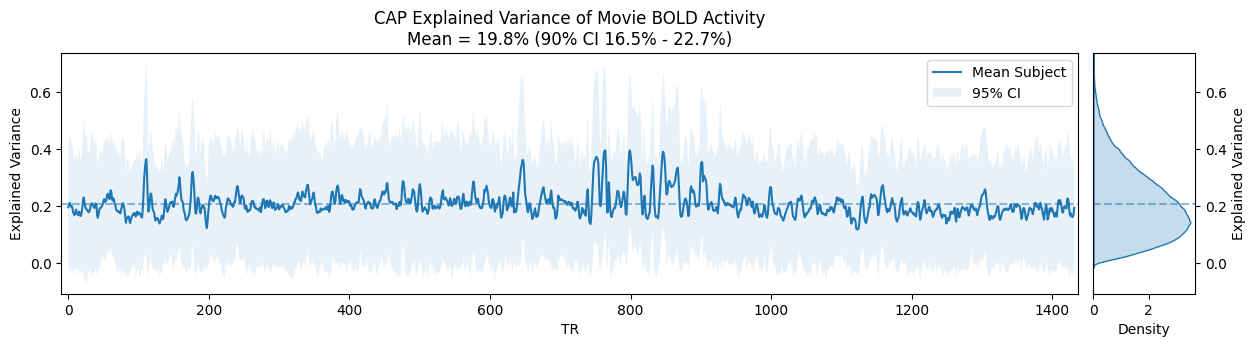

In [472]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 3), gridspec_kw={'width_ratios': [10, 1]})
fig.tight_layout(w_pad=-2)
tr_s = np.arange(ev_s.shape[1])

alpha = 1.96
m, sd = np.mean(ev_s, axis=0), np.std(ev_s, axis=0)
a0.plot(tr_s, m, label="Mean Subject")
a0.fill_between(tr_s, m - alpha * sd, m + alpha * sd, alpha=0.1, label=f"95% CI")
a0.set(xlabel="TR", title=f"CAP Explained Variance of Movie BOLD Activity\n{s}",
       ylabel="Explained Variance")
a0.axhline(np.mean(ev_s), linestyle="--", alpha=0.5)
a0.set_xlim(-10, ev_s.shape[1] + 5)
a0.legend()

a1.yaxis.tick_right()
a1.yaxis.set_label_position("right")
sns.kdeplot(y=ev_s.ravel(), ax=a1, fill=True, bw_method=0.05)
a1.axhline(np.mean(ev_s), linestyle="--", alpha=0.5)
a1.set_ylim(a0.get_ylim())
a1.set(ylabel="Explained Variance")